In [1]:
from sklearn.datasets import fetch_california_housing

from EDA import preprocessing

x, y = fetch_california_housing(return_X_y=True, as_frame=True)
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [2]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


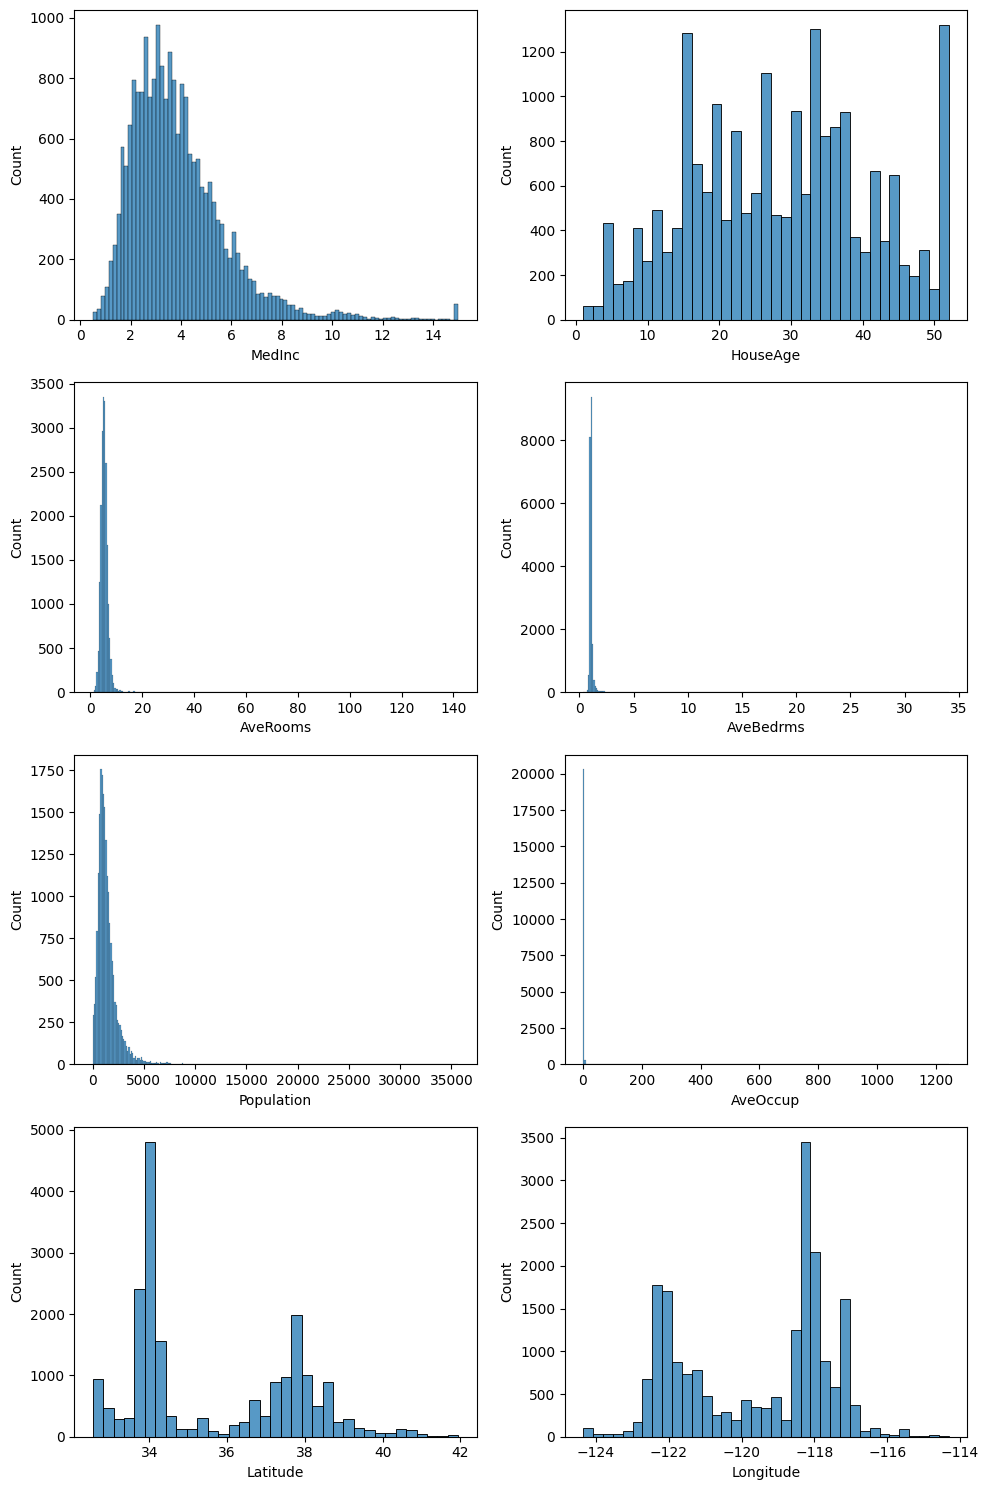

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(4, 2, figsize=(10, 15))

for ax, col in zip(axs.ravel(), x.columns):
    sns.histplot(x[col], ax=ax)

plt.tight_layout()
plt.show()

<Axes: xlabel='Longitude', ylabel='Latitude'>

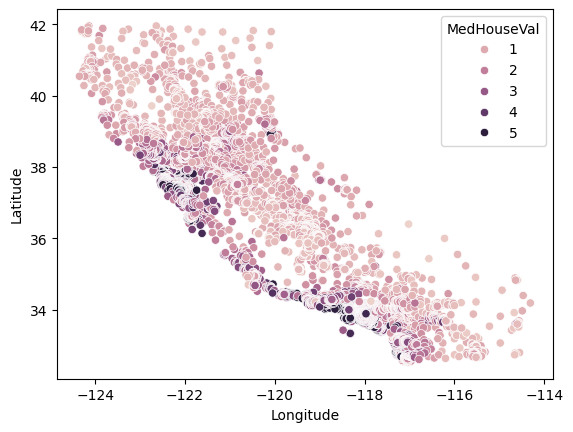

In [15]:
sns.scatterplot(x=x["Longitude"], y =x["Latitude"], hue=y)

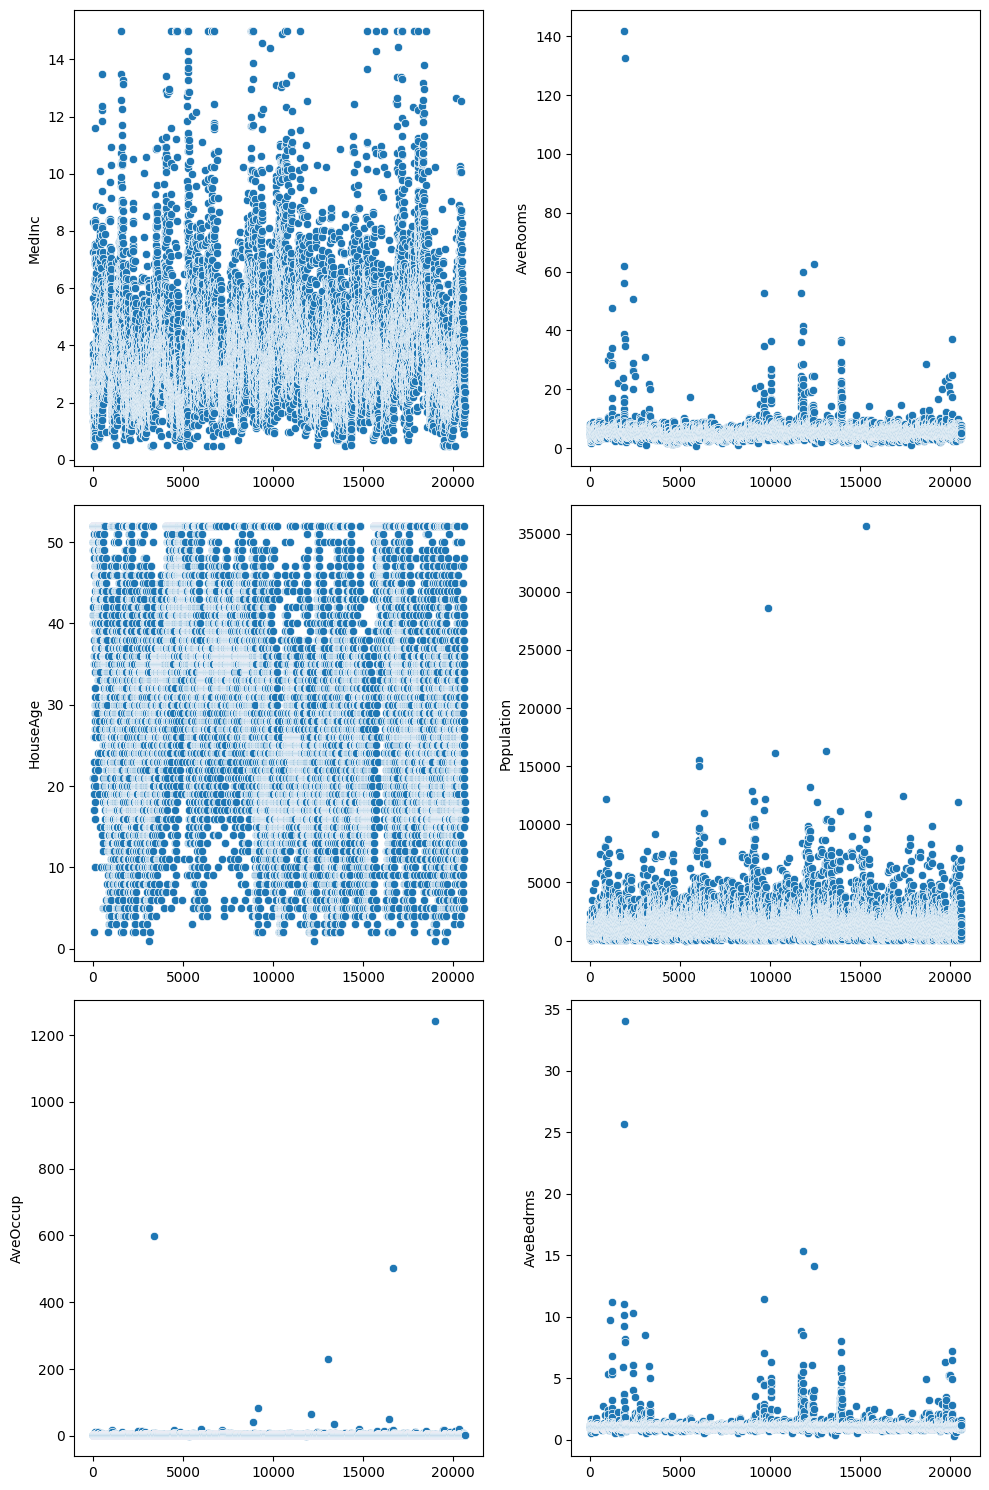

In [18]:
cols = set(x.colums)

fig, axs = plt.subplots(3, 2, figsize=(10, 15))
for ax, col in zip(axs.ravel(), cols):
    sns.scatterplot(x[col], ax=ax)
plt.tight_layout()


In [21]:
from sklearn.model_selection import train_test_split

x_train, x_testval, y_train, y_testval = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_testval, y_testval, test_size=0.5, random_state=42)


In [23]:
Q1 = x_train.quantile(.25)
Q3 = x_train.quantile(.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x_train_capped = x_train.copy()
x_test_capped = x_test.copy()
x_val_capped = x_val.copy()

for col in cols:
    x_train_capped[col] = x_train_capped[col] - lower_bound[col]
    x_test_capped[col] = x_test_capped[col] - lower_bound[col]
    x_val_capped[col] = x_val_capped[col] - lower_bound[col]

x_train = x_train_capped
x_test = x_test_capped
x_val = x_val_capped

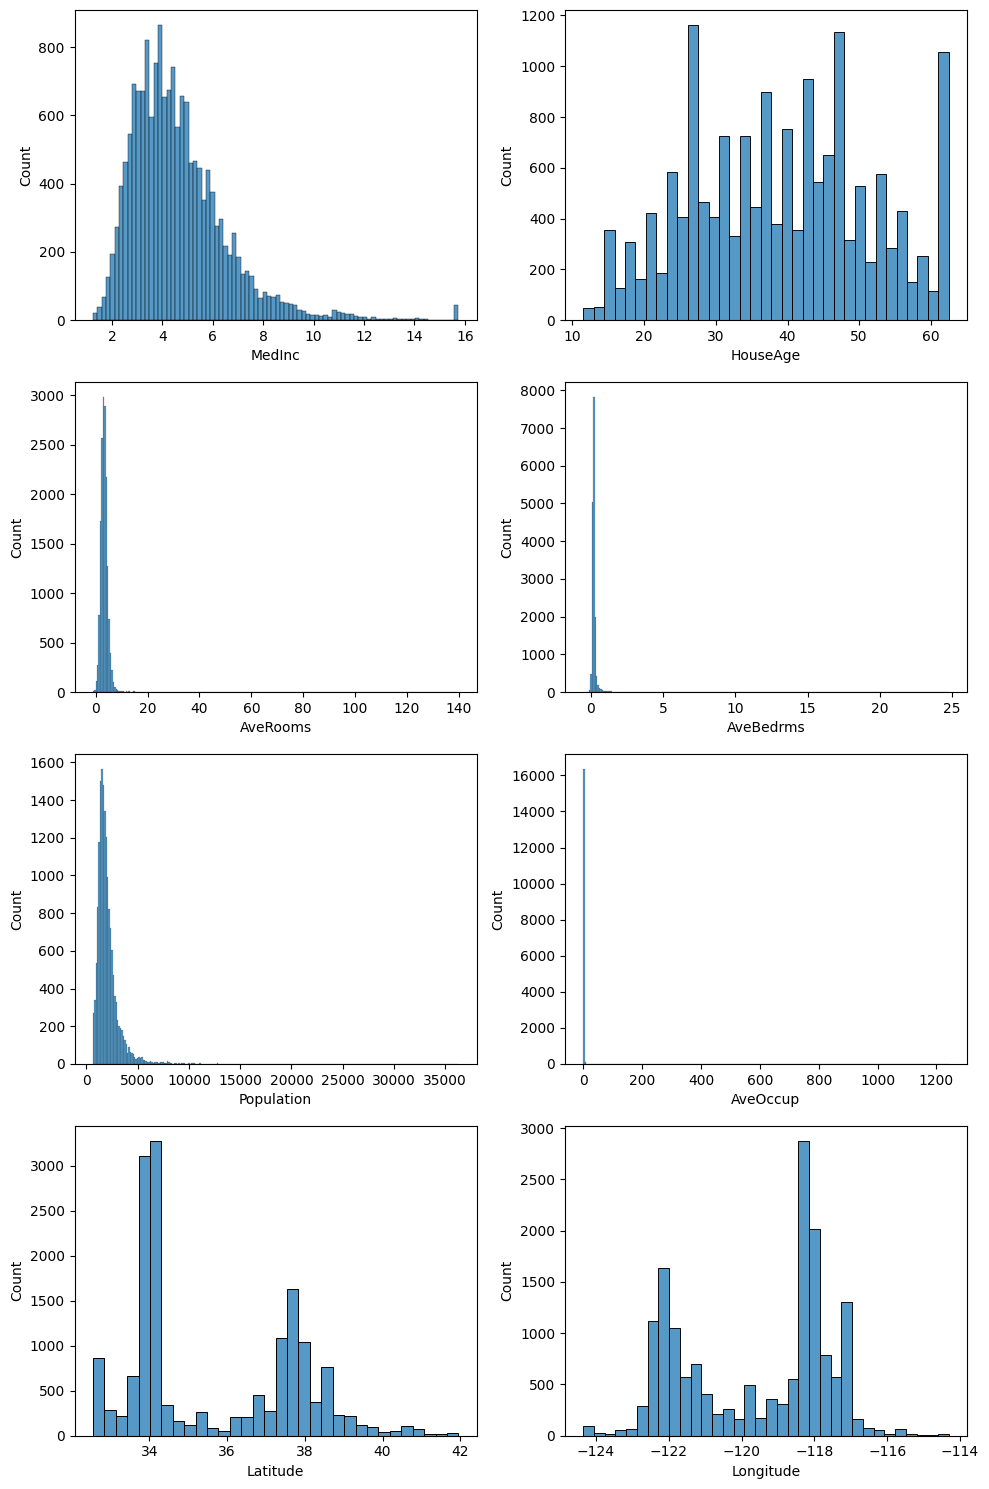

In [24]:
fig, axs = plt.subplots(4, 2, figsize=(10, 15))

for ax, col in zip(axs.ravel(), x):
    sns.histplot(x_train[col], ax=ax)

plt.tight_layout()
plt.show()

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

preprocessing = make_pipeline(
    ColumnTransformer(transformers=[
        ("min", MinMaxScaler(), x.columns),
    ])
)

In [26]:
x_train_processed = preprocessing.fit_transform(x_train)
x_test_processed = preprocessing.transform(x_test)
x_val_processed = preprocessing.transform(x_val)